Task 1 : Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

Task 2 : Upload Dataset ( Done manually )

Task 3 : Load Dataset

In [6]:
from openpyxl import load_workbook

wb = load_workbook("online_retail_II.xlsx", read_only=True)

print("Available Sheets:")
print(wb.sheetnames)

Available Sheets:
['Year 2009-2010', 'Year 2010-2011']


In [7]:
df1 = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2009-2010",
    engine="openpyxl"
)

df2 = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2010-2011",
    engine="openpyxl"
)

df = pd.concat([df1, df2], ignore_index=True)

Task 4 : Display Basic Information

Shape

In [8]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(1067371, 8)


Columns

In [9]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


Data Types

In [10]:
print(df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


Dataset Information

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


First Five Rows

In [14]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Last Five Rows

In [15]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


Task 5 : Summary Statistics

Numerical Columns

In [16]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


Categorical Columns

In [17]:
df.describe(include='object')

,Invoice,StockCode,Description,Country
count,1067371,1067371,1062989,1067371
unique,53628,5305,5698,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1350,5829,5918,981330


Task 6 : Missing Values

In [50]:
missing = df.isnull().sum()

missing_percent = (missing/len(df))*100

missing_table = pd.DataFrame({
    "Missing Values":missing,
    "Percentage":missing_percent
})

print("Missing Values:")
print(missing_table)

Missing Values:
             Missing Values  Percentage
Invoice                   0    0.000000
StockCode                 0    0.000000
Description            4382    0.410541
Quantity                  0    0.000000
InvoiceDate               0    0.000000
Price                     0    0.000000
Customer ID          243007   22.766873
Country                   0    0.000000
Revenue                   0    0.000000
Month                     0    0.000000


Missing Values Heatmap

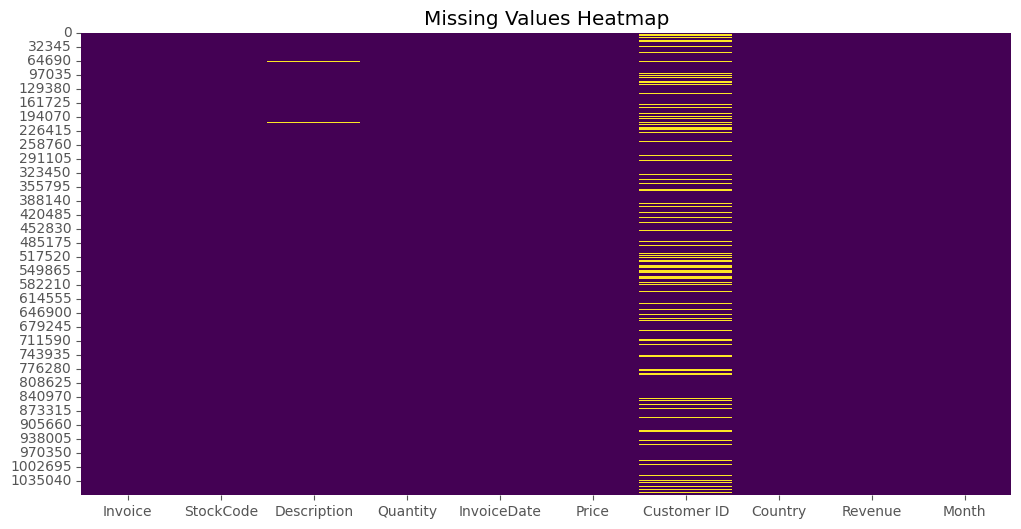

In [37]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

Task 7 : Duplicate Rows

In [51]:
duplicate_rows = df[df.duplicated()]

print("Total Duplicate Rows:", len(duplicate_rows))

duplicate_rows.head()

Total Duplicate Rows: 34335


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,3.75,2009-12
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,5.10,2009-12
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom,7.80,2009-12
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,3.75,2009-12
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,3.75,2009-12


In [21]:
df[df.duplicated()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067136,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
1067150,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
1067153,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
1067160,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


Task 8 : Create Revenue Column

In [22]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [23]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


Task 9 : Top 10 Best Selling Products (Quantity)

In [24]:
top_quantity = (df.groupby("Description")["Quantity"]
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))

top_quantity

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,108545
WHITE HANGING HEART T-LIGHT HOLDER,93050
ASSORTED COLOUR BIRD ORNAMENT,81306
JUMBO BAG RED RETROSPOT,78090
BROCADE RING PURSE,70700
PACK OF 60 PINK PAISLEY CAKE CASES,56575
60 TEATIME FAIRY CAKE CASES,54366
SMALL POPCORN HOLDER,49616
PACK OF 72 RETROSPOT CAKE CASES,49344


Plot

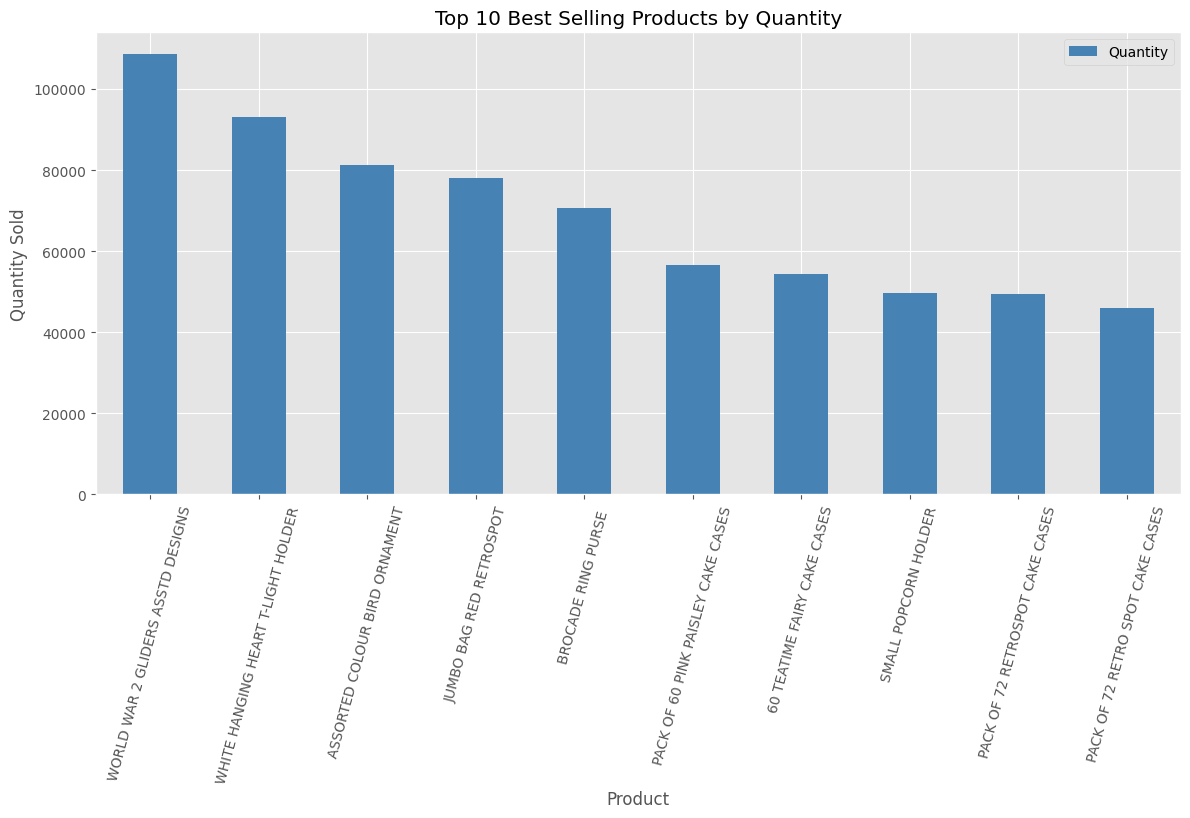

In [38]:
plt.figure(figsize=(14,6))

top_quantity.plot(kind='bar',
                  color='steelblue')

plt.title("Top 10 Best Selling Products by Quantity")

plt.xlabel("Product")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=75)

plt.legend(["Quantity"])

plt.show()

Task 10 : Top 10 Products by Revenue

In [26]:
top_revenue = (df.groupby("Description")["Revenue"]
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))

top_revenue

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,327813.65
DOTCOM POSTAGE,322647.47
WHITE HANGING HEART T-LIGHT HOLDER,257533.90
JUMBO BAG RED RETROSPOT,148800.64
PARTY BUNTING,147948.50
ASSORTED COLOUR BIRD ORNAMENT,131413.85
PAPER CHAIN KIT 50'S CHRISTMAS,121662.14
POSTAGE,112341.00
CHILLI LIGHTS,84854.16


Plot

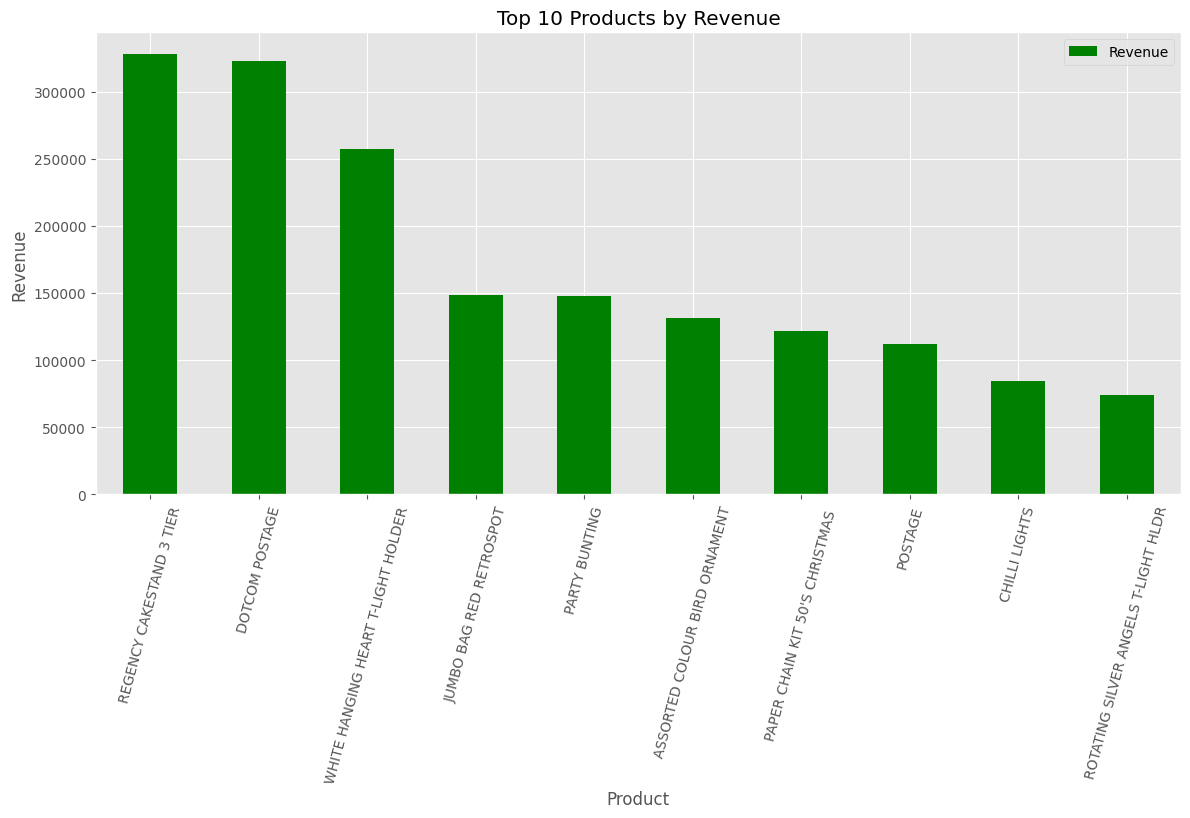

In [39]:
plt.figure(figsize=(14,6))

top_revenue.plot(kind='bar',
                 color='green')

plt.title("Top 10 Products by Revenue")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.xticks(rotation=75)

plt.legend(["Revenue"])

plt.show()

Task 11 : Sales Performance by Country

In [28]:
country_sales = (df.groupby("Country")["Revenue"]
                   .sum()
                   .sort_values(ascending=False))

country_sales.head(10)

,Revenue
Country,
United Kingdom,1.638258e+07
EIRE,6.155196e+05
Netherlands,5.485249e+05
Germany,4.179886e+05
France,3.281918e+05
Australia,1.671291e+05
Switzerland,9.972876e+04
Spain,9.185948e+04
Sweden,8.780942e+04


Plot

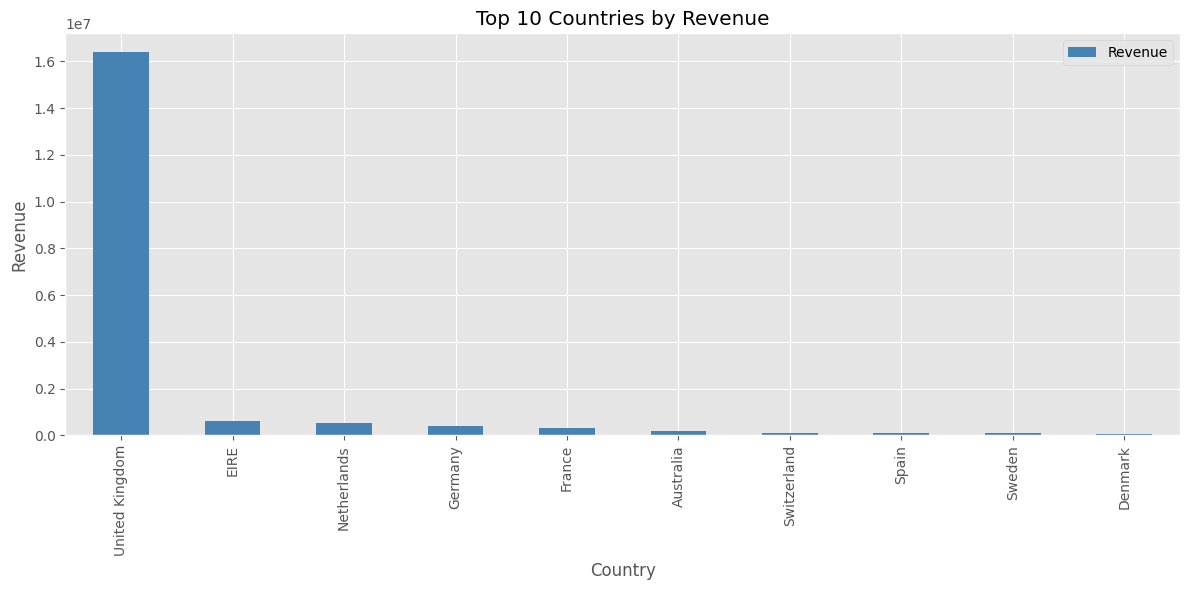

In [52]:
plt.figure(figsize=(12,6))

country_sales.head(10).plot(
    kind='bar',
    color='steelblue'
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.legend(["Revenue"])

plt.tight_layout()

plt.show()

Task 12 : Monthly Revenue Trend

Convert InvoiceDate

In [30]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

Create Month column

In [31]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

Monthly Revenue

In [32]:
monthly = df.groupby("Month")["Revenue"].sum()

Plot

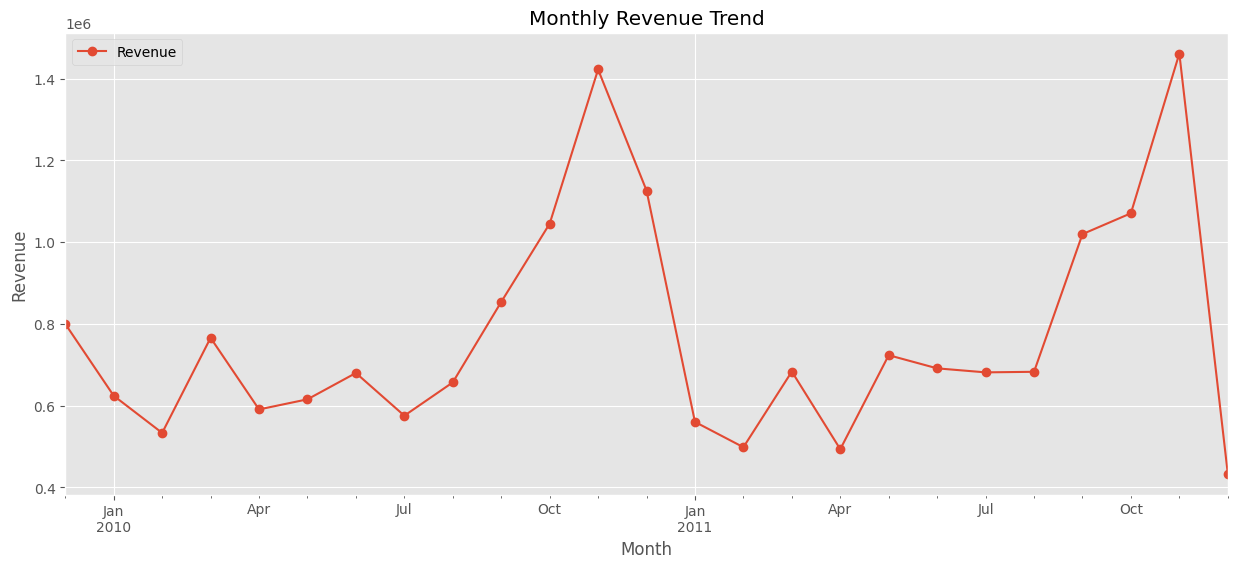

In [41]:
plt.figure(figsize=(15,6))

monthly.plot(marker='o')

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.legend(["Revenue"])

plt.grid(True)

plt.show()

Task 13 : Correlation Heatmap

In [42]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

Plot

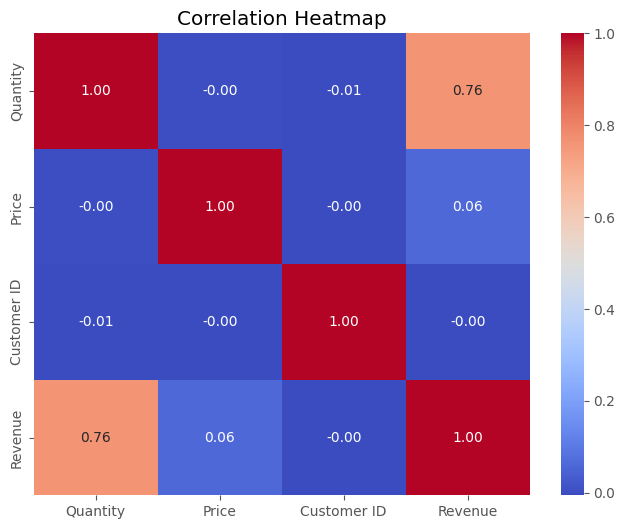

In [43]:
plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

Task 14 : Detect Outliers

Quantity

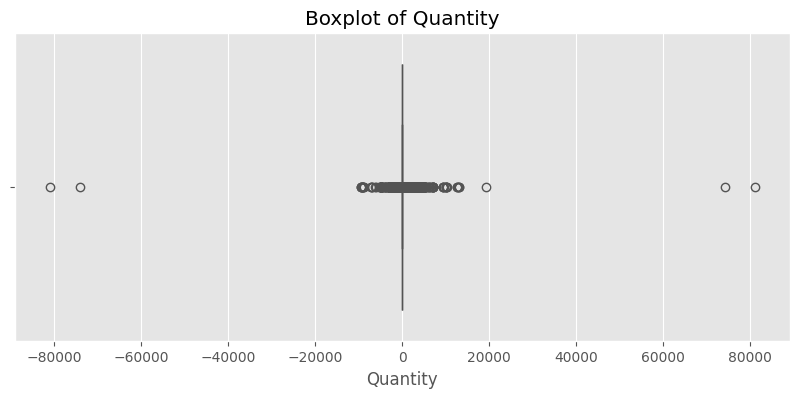

In [44]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["Quantity"])

plt.title("Boxplot of Quantity")

plt.show()

Price

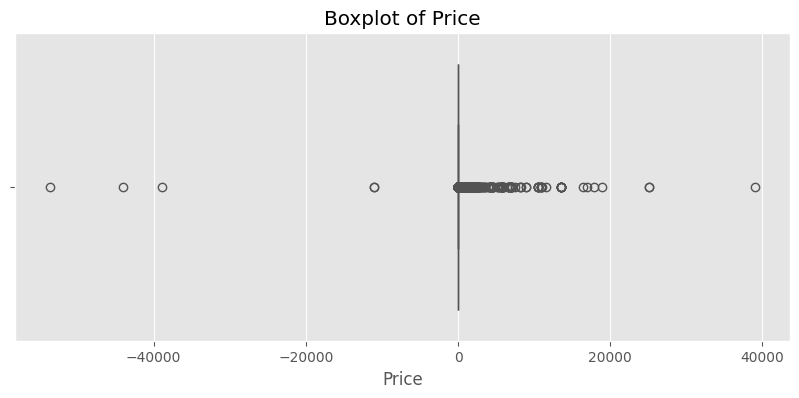

In [45]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["Price"])

plt.title("Boxplot of Price")

plt.show()

Revenue

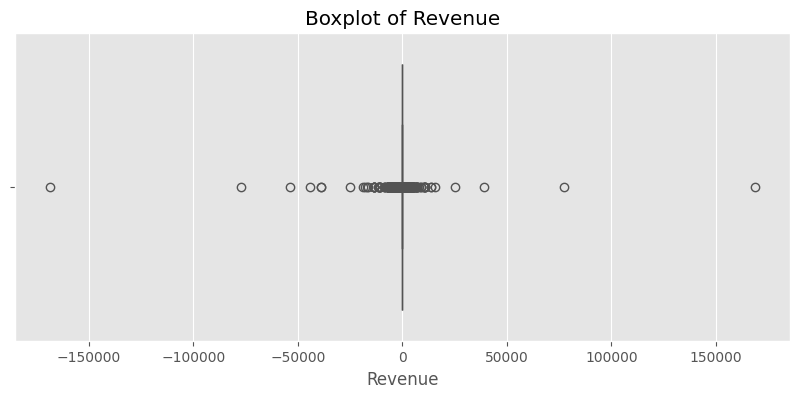

In [46]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["Revenue"])

plt.title("Boxplot of Revenue")

plt.show()

Task 15 : Revenue Distribution

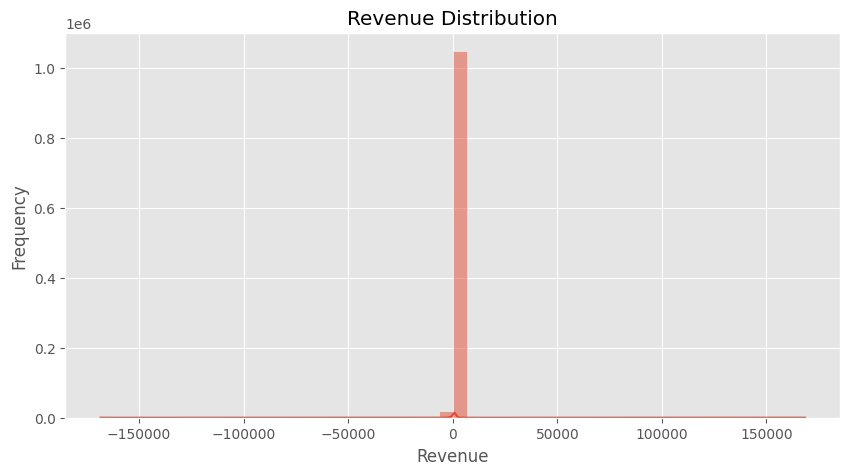

In [48]:
plt.figure(figsize=(10,5))

sns.histplot(df["Revenue"],
             bins=50,
             kde=True)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()

Task 16 : Top Customers

In [49]:
top_customers = (df.groupby("Customer ID")["Revenue"]
                   .sum()
                   .sort_values(ascending=False)
                   .head(10))

top_customers

,Revenue
Customer ID,
18102.0,598215.22
14646.0,523342.07
14156.0,296564.69
14911.0,270248.53
17450.0,233579.39
13694.0,190825.52
17511.0,171885.98
12415.0,143269.29
16684.0,141502.25


Task 17 : Business Insights


Business Insights
1.The United Kingdom contributes the highest revenue, making it the retailer's primary market.
2.A small number of products account for a significant portion of sales, indicating that maintaining inventory for these items is essential.
3.Revenue varies considerably across countries, suggesting opportunities to expand marketing in underperforming regions.
4.Monthly revenue exhibits seasonal fluctuations, with higher sales during holiday periods.
5.Box plots reveal numerous outliers in Quantity, Price, and Revenue, indicating bulk purchases, product returns (negative quantities), and premium-priced items.
6.The dataset contains missing Customer IDs and duplicate rows, which should be addressed before building recommendation or predictive models.

Task 18 : Conclusion

This exploratory data analysis examined customer purchase behavior, product performance, country-wise sales, monthly revenue trends, and data quality. The analysis identified missing values, duplicate records, outliers, and sales patterns without modifying the data. These findings provide a strong foundation for future data cleaning, feature engineering, and recommendation system development.